# NYC Airbnb Room Type Classification

**Dataset:** [New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) (Kaggle)

**Goal:** Predict the `room_type` of an Airbnb listing (`Entire home/apt`, `Private room`, or `Shared room`)
using listing attributes such as price, location, availability, and review activity.

**What this notebook covers (the full ML lifecycle):**

1. Problem framing & data loading
2. Exploratory Data Analysis (EDA) — univariate, bivariate, skewness, outliers
3. Data cleaning & feature engineering
4. Train / test split
5. Preprocessing with `ColumnTransformer` + `Pipeline`
6. Baseline model
7. Multiple candidate algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
8. Model comparison (cross-validation)
9. Hyperparameter tuning of the best model
10. Final evaluation on the untouched test set
11. Feature importance
12. Saving the final pipeline (model artifact)
13. Conclusion & next steps



## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The raw CSV downloaded from Kaggle is read directly into a pandas DataFrame.

In [2]:
import kagglehub
import os # Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


In [3]:
df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))

In [4]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [6]:
df.shape

(48895, 16)

## 3. Exploratory Data Analysis (EDA)

We explore the data in the standard order every ML engineer follows:

- Missing values
- Univariate analysis (one variable at a time — distributions, skewness)
- Bivariate analysis (relationship between features and the target)
- Correlation between numeric features
- Outlier inspection


### 3.1 Missing Values

In [7]:
missing=df.isna().sum()
missing[missing>0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


In [8]:
df.duplicated().sum()

np.int64(0)

### 3.2 Target Variable — `room_type`

In [9]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

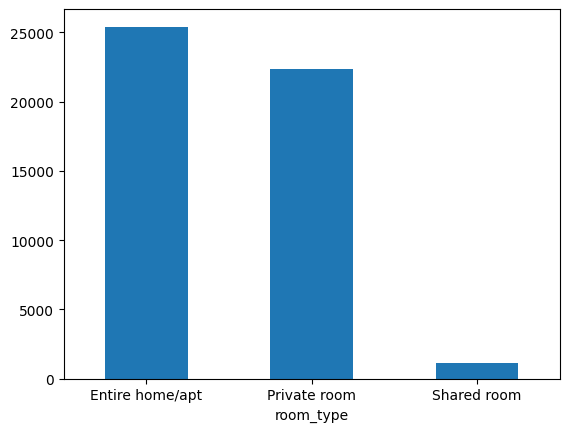

In [10]:
df['room_type'].value_counts().plot(kind='bar')
plt.xticks(rotation=0)
plt.show()

The classes are imbalanced -> Shared Room is a Small Minority.

### 3.3 Univariate Analysis — Numeric Features

In [11]:
num_cols=df.select_dtypes(include="number").columns

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'host_id'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>],
       [<Axes: title={'center': 'availability_365'}>, <Axes: >, <Axes: >]],
      dtype=object)

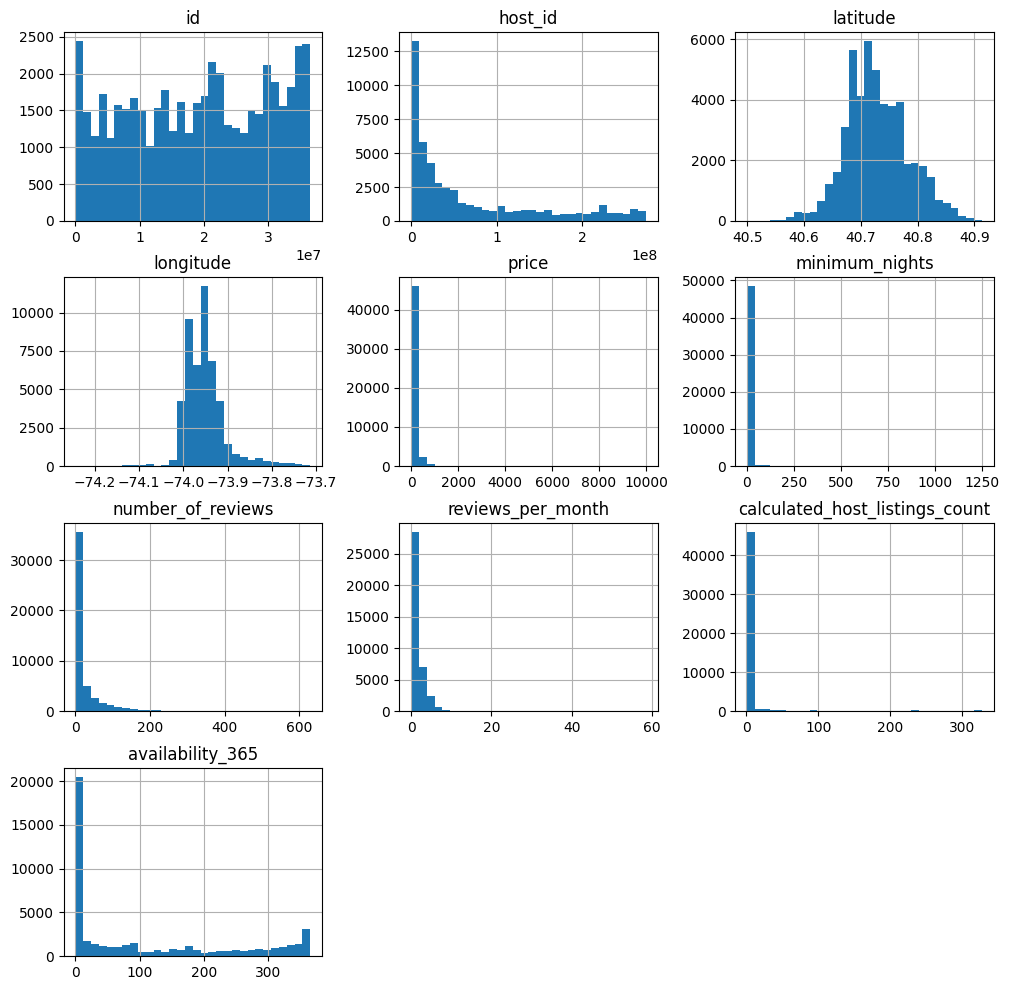

In [12]:
df[num_cols].hist(bins=30,figsize=(12,12))

### 3.4 Univariate Analysis — Categorical Features

<Axes: xlabel='neighbourhood_group', ylabel='count'>

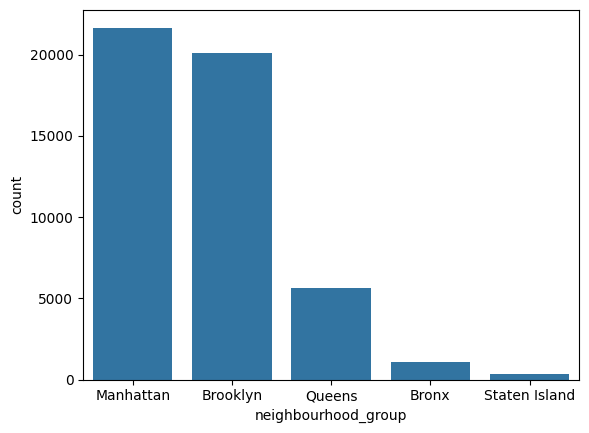

In [13]:
sns.countplot(data=df,x='neighbourhood_group',order=df['neighbourhood_group'].value_counts().index)

### 3.5 Bivariate Analysis — Features vs Target

<Axes: xlabel='room_type', ylabel='price'>

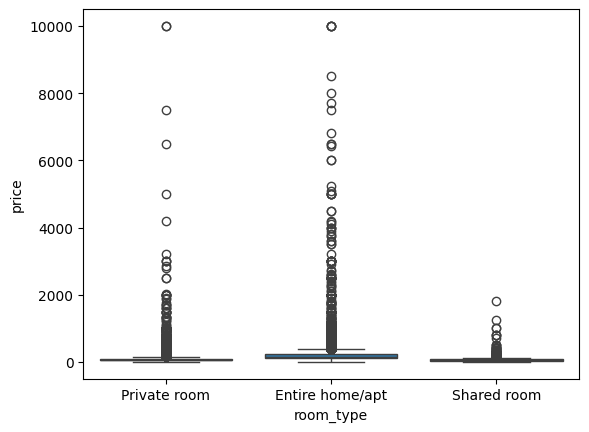

In [14]:
sns.boxplot(data=df,x='room_type',y='price')

### 3.6 Correlation Between Numeric Features

<Axes: >

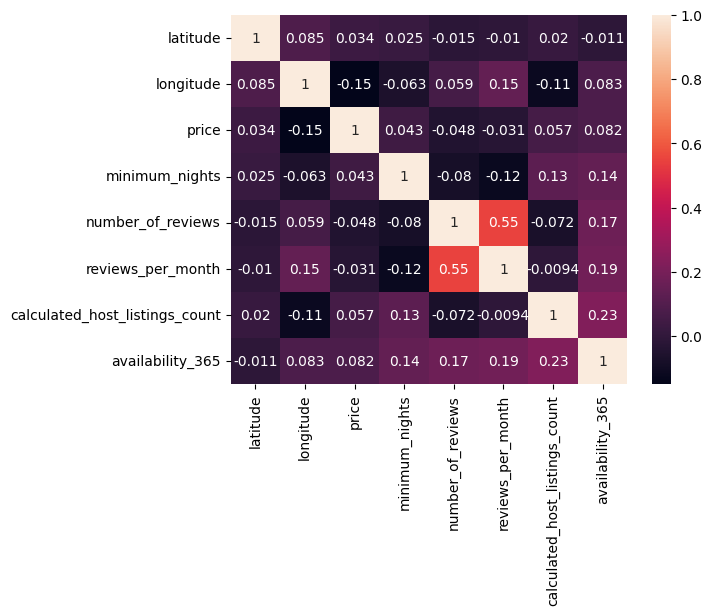

In [15]:
num_cols = df.select_dtypes(include="number").columns
num_cols = num_cols.drop(["id","host_id"])
corr=df[num_cols].corr()
sns.heatmap(corr,annot=True)

### 3.7 Geographic Distribution (Bonus Visual)

<Axes: xlabel='longitude', ylabel='latitude'>

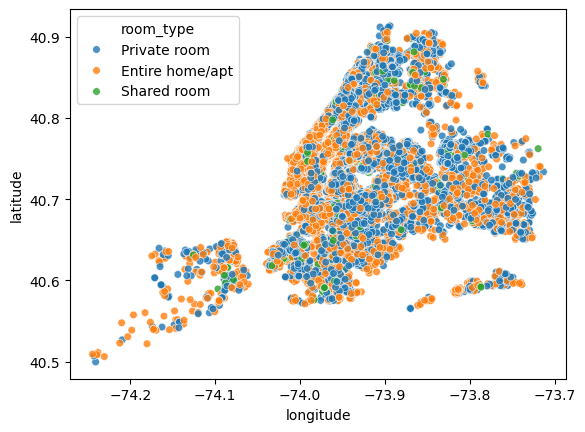

In [16]:
sns.scatterplot(data=df,x='longitude',y='latitude',hue='room_type',s=30,alpha=0.8)

## 4. Data Cleaning & Feature Engineering

Steps:
1. Drop columns that are pure identifiers or free text and carry no generalizable signal for a
   tabular model (`id`, `name`, `host_id`, `host_name`, `last_review`).
2. Fill missing `reviews_per_month` with `0` (no reviews yet).
3. Cap extreme outliers in `price` and `minimum_nights` using percentile clipping, so a handful of
   data-entry errors (e.g. $10,000/night, 1,250 minimum nights) don't distort the model.
4. Separate features (`X`) from the target (`y`).


In [17]:
df_clean=df.drop(columns=['id','name','host_id','host_name','last_review'])

In [18]:
df_clean['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [19]:
df[['price','minimum_nights']].describe()

,price,minimum_nights
count,48895.000000,48895.000000
mean,152.720687,7.029962
std,240.154170,20.510550
min,0.000000,1.000000
25%,69.000000,1.000000
50%,106.000000,3.000000
75%,175.000000,5.000000
max,10000.000000,1250.000000


In [20]:
price_cap=df_clean['price'].quantile(0.99)
nights_cap=df_clean['minimum_nights'].quantile(0.99)

df_clean['price']=df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights']=df_clean['minimum_nights'].clip(upper=nights_cap)

# df_clean=df_clean[df['price']<price_cap]
# df_clean=df_clean[df['minimum_nights']<nights_cap]

In [21]:
X=df_clean.drop(columns=['room_type'],axis=1)
y=df_clean['room_type']

## 5. Train / Test Split

We hold out 20% of the data as a **test set** that is never touched during model selection or
tuning — it is only used once, at the very end, to report the final, honest performance.
`stratify=y` keeps the same class proportions in both splits, which matters because the target is
imbalanced.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42,stratify=y)

In [23]:
 # staratisy ensures that when we split or sample, then orignal proportion of each class is maintained

## 6. Preprocessing: `ColumnTransformer` + `Pipeline`

Production ML code should never manually transform train/test data with separate lines — it's
error-prone and leaks information. Instead we build a single, reusable `ColumnTransformer`:

- **Numeric features** → median imputation + standard scaling
- **Categorical features** → most-frequent imputation + one-hot encoding

This transformer will be the first step of *every* model pipeline below, so preprocessing is
learned only on training data and applied consistently everywhere (no data leakage).

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer,PowerTransformer
from sklearn.compose import ColumnTransformer

In [25]:
df_clean[num_cols].skew()

,0
latitude,0.237167
longitude,1.284210
price,2.776321
minimum_nights,2.360347
number_of_reviews,3.690635
reviews_per_month,3.300723
calculated_host_listings_count,7.933174
availability_365,0.763408


In [26]:
#almost all num cols skwed so we first correct skew
skwed_num_cols=['latitude','longitude','price','minimum_nights','number_of_reviews',
       'reviews_per_month','calculated_host_listings_count','availability_365']
categ_cols=['neighbourhood_group','neighbourhood']

In [27]:
# we can use log1- func tranformer but now we use PowerTransformer (as it also hanldes -ve good )
numeric_skew_pipeline=Pipeline(
    steps=[
          ("impute",SimpleImputer(strategy="median")),
          # ("tranform",PowerTransformer(method="yeo-johnson")),   removed bcz causing error in model train maybe we fill many 0 or whatever
        # ("tranform",FunctionTransformer(np.log1p)),
          ("scale",StandardScaler())]
)

categorical_pipeline=Pipeline(
    steps=[("impute",SimpleImputer(strategy="most_frequent")),
           ("encode",OneHotEncoder(handle_unknown="ignore"))]
)

In [28]:
preprocess=ColumnTransformer(
    transformers=[("numerical",numeric_skew_pipeline,num_cols),
                 ("categorical",categorical_pipeline,categ_cols)]
)
preprocess

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

## 8. Trying Multiple Algorithms

We now compare several models, each wrapped in its own pipeline with the **same** preprocessor. We
evaluate each with 3-fold **stratified cross-validation** on the training set (never touching the
test set yet), so the comparison is fair and robust.

Models tried:
1. Logistic Regression — simple, interpretable linear baseline
2. Decision Tree — a single non-linear model, prone to overfitting
3. Random Forest — an ensemble of trees, usually a strong general-purpose model
4. Gradient Boosting — sequential ensemble, often the most accurate of the classics


I self added KNN and SVM too

**SMOTE (Synthetic Minority Oversampling)**.                         
for class IMbalance
-----------------------------------------
Disadvantages :
1. High chances of Overfitting.
2. Data Leakage


supose we encode ex room type
it gives 0,1,2 (minority->2) but when fill synthetic vlaues it can give 0.6,1,1.7 but 0.6,1.7 is of no class and
1 refer to majority

<h3>so we use class weights:</h3>
dont fill synthietic values
focus on all class equal but more focus on minority class

In [29]:
import warnings
warnings.filterwarnings("ignore")

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [31]:
from sklearn.model_selection import cross_validate

#class_wieght="balanced" -> tells model to pay more attention to minority class
# but problem is KNN,Gradient Boosting not support
models={
    "Logistic Regression":LogisticRegression(class_weight="balanced",random_state=42),
    "Decision Tree":DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "Random Forest":RandomForestClassifier(class_weight="balanced",random_state=42),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42),

    "KNN":KNeighborsClassifier(),
    "SVM":SVC(class_weight="balanced",random_state=42)
}


for name,model in models.items():

  pipe=Pipeline(
      steps=[("preprocessor",preprocess),
             ("classifier",model)]
  )
# accuracy alone can be misleading on imbalanced class -> we use macro f1
# both plain accuracy and macro f1 (which treat every class equal)

  # accuracy=cross_val_score(pipe,X_train,y_train,cv=3,scoring="accuracy")
  # macrof1=cross_val_score(pipe,X_train,y_train,cv=3,scoring="f1_macro")

  # above code fit 3 tiems then again total 6 fits expensive, alt-> cordd validate

  scores = cross_validate(pipe,X_train,y_train,cv=3,scoring=["accuracy", "f1_macro"])
  print("\n")
  print(name)
  print("------------------------------------------------------")
  print(f"Accuracy: {scores['test_accuracy'].mean():.3f}")
  print(f"F1: {scores['test_f1_macro'].mean():.3f}")



Logistic Regression
------------------------------------------------------
Accuracy: 0.663
F1: 0.526


Decision Tree
------------------------------------------------------
Accuracy: 0.784
F1: 0.650


Random Forest
------------------------------------------------------
Accuracy: 0.853
F1: 0.718


Gradient Boosting
------------------------------------------------------
Accuracy: 0.850
F1: 0.708


KNN
------------------------------------------------------
Accuracy: 0.783
F1: 0.634


SVM
------------------------------------------------------
Accuracy: 0.782
F1: 0.625


## I added Stacking also for try

In [ ]:
from sklearn.ensemble import StackingClassifier

base_models = [
    ("lr", LogisticRegression(class_weight="balanced",random_state=42)),
    ("rf", RandomForestClassifier(class_weight="balanced", random_state=42)),
    ("knn", KNeighborsClassifier())
]

stacking_model=StackingClassifier(
    estimators=base_models,
    final_estimator=RandomForestClassifier(class_weight="balanced",random_state=42),
    cv=3
)

stack_pipe = Pipeline(
    steps=[("preprocessor", preprocess),
           ("classifier", stacking_model)
    ]
)

scores = cross_validate(stack_pipe,X_train,y_train,cv=3,scoring=["accuracy", "f1_macro"])

print(f"Accuracy: {scores['test_accuracy'].mean():.3f}")
print(f"F1: {scores['test_f1_macro'].mean():.3f}")

## 9. Hyperparameter Tuning

We pick the best-performing model from the comparison above (whichever one that turns out to be) and
search over *its* key hyperparameters using `RandomizedSearchCV` (cheaper than an exhaustive grid
search, while still exploring the space well). We keep optimizing for **macro-F1** since the classes
are imbalanced.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline=Pipeline(
    steps=[('preprocess',preprocess),
           ("classifier",RandomForestClassifier(class_weight="balanced"))]
)

param_grid={
    'classifier__n_estimators':[100,200],
    'classifier__max_depth':[None,10,20],
    'classifier__min_samples_split':[2,5,10],
    'classifier__min_samples_leaf':[1,2,4,8]
}

random_search=RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=2

)

random_search.fit(X_train,y_train)

In [ ]:
best_pipeline_2=Pipeline(
    steps=[("preprocess",preprocess),
           ("classifier",StackingClassifier(estimators=base_models,final_estimator=RandomForestClassifier(class_weight="balanced",random_state=42),cv=3))
           ]
)

param_grid_2={
    'classifier__n_estimators':[100,200],
    'classifier__max_depth':[None,10,20],
    'classifier__min_samples_split':[2,5,10],
    'classifier__min_samples_leaf':[1,2,4,8]
}

random_search=RandomizedSearchCV(
    estimator=best_pipeline_2,
    param_distributions=param_grid_2,
    n_iter=20,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=2

)

random_search.fit(X_train,y_train)

In [ ]:
print(random_search.best_params_)
print(random_search.best_score_)

## 10. Final Evaluation on the Test Set

This is the *only* time we touch the held-out test set. It gives us an honest estimate of how the
final tuned model would perform on completely unseen listings.

## 11. Saving the Final Model Artifact

In production, the entire pipeline (preprocessing **and** model together) is serialized as a single
artifact, so a new listing can be scored with one call  no manual preprocessing required at
inference time.